# Module 7 — GhostBreath Full System Circuit Schematic

**GhostBreath – Self-Powered Cognitive Fatigue Monitor**
Embedded Systems Project · Module 7

This notebook generates the complete hardware circuit schematic for the GhostBreath system.
It covers the full signal chain from body-heat harvesting through CO₂ sensing and fatigue scoring
to audio alerting — showing every real component, connection, and net colour.

## System Overview

| Subsystem | Components |
|-----------|------------|
| Energy harvesting | TEG SP1848-27145SA → LTC3108 DC-DC boost converter → 1 F / 5.5 V supercapacitor |
| Microcontroller | ESP32-WROOM-32 (240 MHz, dual-core) |
| CO₂ / Temp / Humidity | Sensirion SCD41 (I²C 0x62) |
| Display | SSD1306 128×64 OLED (I²C 0x3C) |
| Alert | Passive piezo buzzer driven by GPIO4 via `tone()` at 1 kHz |
| I²C bus | GPIO21 (SDA) and GPIO22 (SCL) with 4.7 kΩ pull-ups to 3.3 V |

## Net colour code

| Colour | Net |
|--------|-----|
| Red | 3.3 V / VCC |
| Black | GND |
| Blue | I²C SDA (GPIO21) |
| Cyan | I²C SCL (GPIO22) |
| Orange | Buzzer signal (GPIO4) |
| Brown | TEG power path |


In [1]:
"""
Display the Wokwi simulation screenshot.
Place your screenshot at  figures/wokwi_simulation_screenshot.png  to see it here.
"""
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

SCREENSHOT = Path("figures/wokwi_simulation_screenshot.png")

if SCREENSHOT.exists():
    img = mpimg.imread(str(SCREENSHOT))
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("GhostBreath — Wokwi Simulation Screenshot", fontsize=13, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()
    print(f"Screenshot loaded from {SCREENSHOT}")
else:
    print(f"Screenshot not found at {SCREENSHOT}")
    print("To display it: save your Wokwi simulation screenshot as figures/wokwi_simulation_screenshot.png")


Screenshot not found at figures/wokwi_simulation_screenshot.png
To display it: save your Wokwi simulation screenshot as figures/wokwi_simulation_screenshot.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Arc, Circle
from pathlib import Path

Path("figures").mkdir(exist_ok=True)

# ── Net colours ──────────────────────────────────────────────────────────────
RED    = "#CC0000"    # 3.3 V / VCC rail
BLK    = "#1A1A1A"   # GND rail / wires
BLUE   = "#1155CC"   # I2C SDA
CYAN   = "#007799"   # I2C SCL
ORANGE = "#DD6600"   # GPIO signals
BROWN  = "#7A3B00"   # TEG power path
GREY   = "#888888"   # Passive components
ICBG   = "#EBF4FB"   # IC fill
ICFG   = "#1A3A5C"   # IC border + title
SENBG  = "#EBF7EC"   # Sensor IC fill
SENFG  = "#1A4A1F"   # Sensor IC border
OLDBG  = "#EBF0FF"   # OLED IC fill
OLDFG  = "#1A1A6E"   # OLED IC border


# ── draw_ic_box ───────────────────────────────────────────────────────────────
def draw_ic_box(ax, x, y, w, h, title, subtitle="",
                left_pins=None, right_pins=None,
                fc=ICBG, ec=ICFG, tsz=9):
    """Draw a labelled IC rectangle; returns dict of pin endpoint coords."""
    rect = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.06",
                          facecolor=fc, edgecolor=ec, linewidth=2, zorder=3)
    ax.add_patch(rect)
    ty = y + h * 0.62 if subtitle else y + h / 2
    ax.text(x + w / 2, ty, title,
            ha="center", va="center", fontsize=tsz, fontweight="bold",
            color=ec, zorder=4)
    if subtitle:
        ax.text(x + w / 2, y + h * 0.33, subtitle,
                ha="center", va="center", fontsize=6.5, color="#555", zorder=4)

    PIN_LEN = 0.28
    PF = 6.5
    pins = {}

    if left_pins:
        n = len(left_pins)
        for i, (pname, pcolor) in enumerate(left_pins):
            py = y + h - h / (n + 1) * (i + 1)
            ax.plot([x - PIN_LEN, x], [py, py], color=pcolor, lw=1.5, zorder=3)
            ax.text(x + 0.10, py, pname,
                    ha="left", va="center", fontsize=PF, color=pcolor, zorder=4)
            pins[f"L_{pname}"] = (x - PIN_LEN, py)

    if right_pins:
        n = len(right_pins)
        for i, (pname, pcolor) in enumerate(right_pins):
            py = y + h - h / (n + 1) * (i + 1)
            ax.plot([x + w, x + w + PIN_LEN], [py, py], color=pcolor, lw=1.5, zorder=3)
            ax.text(x + w - 0.10, py, pname,
                    ha="right", va="center", fontsize=PF, color=pcolor, zorder=4)
            pins[f"R_{pname}"] = (x + w + PIN_LEN, py)

    return pins


def draw_gnd(ax, x, y):
    """Standard ground symbol pointing downward from (x, y)."""
    ax.plot([x, x], [y, y - 0.22], BLK, lw=2, zorder=3)
    for i, hw in enumerate([0.33, 0.22, 0.11]):
        yy = y - 0.22 - i * 0.13
        ax.plot([x - hw, x + hw], [yy, yy], BLK, lw=2, zorder=3)


def draw_vcc(ax, x, y, label="3.3V"):
    """VCC power symbol pointing upward from (x, y)."""
    ax.plot([x, x], [y, y + 0.22], RED, lw=2, zorder=3)
    ax.plot([x - 0.22, x + 0.22], [y + 0.22, y + 0.22], RED, lw=2.5, zorder=3)
    ax.text(x, y + 0.42, label,
            ha="center", va="bottom", fontsize=7, color=RED,
            fontweight="bold", zorder=4)


def dot(ax, x, y, color=BLK, r=0.055):
    """Junction dot."""
    ax.add_patch(Circle((x, y), r, color=color, zorder=5))


def wire(ax, pts, color=BLK, lw=1.5):
    """Draw a polyline through pts = [(x,y), ...]."""
    xs, ys = zip(*pts)
    ax.plot(xs, ys, color=color, lw=lw,
            solid_capstyle="round", solid_joinstyle="round", zorder=2)


def draw_resistor_h(ax, x, y, length, label="", color=GREY):
    """Horizontal zigzag resistor from (x,y) to (x+length, y)."""
    pad = length * 0.18
    body = length - 2 * pad
    n = 6
    xs = np.linspace(x + pad, x + pad + body, 2 * n + 1)
    ys = np.zeros(2 * n + 1)
    ys[1::2] = 0.10
    ys[2::2] = -0.10
    ax.plot([x, x + pad], [y, y], color=color, lw=1.5, zorder=3)
    ax.plot(xs, ys + y, color=color, lw=1.5, zorder=3)
    ax.plot([x + pad + body, x + length], [y, y], color=color, lw=1.5, zorder=3)
    if label:
        ax.text(x + length / 2, y + 0.20, label,
                ha="center", va="bottom", fontsize=6.5, color="#444", zorder=4)


def draw_resistor_v(ax, x, y_bot, height, label="", color=GREY):
    """Vertical zigzag resistor from (x, y_bot) to (x, y_bot+height)."""
    pad = height * 0.18
    body = height - 2 * pad
    n = 6
    ys = np.linspace(y_bot + pad, y_bot + pad + body, 2 * n + 1)
    xs = np.zeros(2 * n + 1)
    xs[1::2] = 0.09
    xs[2::2] = -0.09
    ax.plot([x, x], [y_bot, y_bot + pad], color=color, lw=1.5, zorder=3)
    ax.plot(xs + x, ys, color=color, lw=1.5, zorder=3)
    ax.plot([x, x], [y_bot + pad + body, y_bot + height], color=color, lw=1.5, zorder=3)
    if label:
        ax.text(x + 0.17, y_bot + height / 2, label,
                ha="left", va="center", fontsize=6.5, color="#444", zorder=4)


def draw_cap_v(ax, x, y_bot, height, label="", color=GREY):
    """Vertical capacitor symbol (ceramic/electrolytic) from y_bot to y_bot+height."""
    mid = y_bot + height / 2
    ax.plot([x, x], [y_bot, mid - 0.13], color=color, lw=1.5, zorder=3)
    ax.plot([x - 0.26, x + 0.26], [mid - 0.13, mid - 0.13], color=color, lw=2.5, zorder=3)
    ax.plot([x - 0.26, x + 0.26], [mid + 0.13, mid + 0.13], color=color, lw=2.5, zorder=3)
    ax.plot([x, x], [mid + 0.13, y_bot + height], color=color, lw=1.5, zorder=3)
    if label:
        ax.text(x + 0.38, mid, label,
                ha="left", va="center", fontsize=6.5, color="#444", zorder=4)


def draw_supercap_v(ax, x, y_bot, height, label=""):
    """Vertical supercapacitor (electrolytic with + marker)."""
    mid = y_bot + height / 2
    ax.plot([x, x], [y_bot, mid - 0.13], GREY, lw=1.5, zorder=3)
    # Flat plate (−)
    ax.plot([x - 0.26, x + 0.26], [mid - 0.13, mid - 0.13], GREY, lw=2.5, zorder=3)
    # Curved plate (+)
    theta = np.linspace(-np.pi / 2, np.pi / 2, 40)
    ax.plot(x + 0.12 * np.cos(theta), mid + 0.13 + 0.26 * np.sin(theta),
            GREY, lw=2.5, zorder=3)
    ax.plot([x, x], [mid + 0.13, y_bot + height], GREY, lw=1.5, zorder=3)
    ax.text(x - 0.34, mid + 0.09, "+", ha="center", va="bottom",
            fontsize=9, color=RED, fontweight="bold", zorder=4)
    if label:
        ax.text(x + 0.40, mid, label,
                ha="left", va="center", fontsize=6.5, color="#444", zorder=4)


def draw_source_v(ax, cx, y_bot, height, v_label="", name_label=""):
    """Vertical voltage source circle; leads at (cx, y_bot) and (cx, y_bot+height)."""
    r = height * 0.38
    cy = y_bot + height / 2
    ax.add_patch(Circle((cx, cy), r, fill=False, edgecolor=BROWN, lw=2, zorder=3))
    ax.plot([cx, cx], [y_bot, cy - r], BROWN, lw=2, zorder=3)
    ax.plot([cx, cx], [cy + r, y_bot + height], BROWN, lw=2, zorder=3)
    ax.text(cx, cy + r * 0.42, "+", ha="center", va="center",
            fontsize=10, color=BROWN, fontweight="bold", zorder=4)
    ax.text(cx, cy - r * 0.42, "−", ha="center", va="center",
            fontsize=12, color=BROWN, zorder=4)
    if v_label:
        ax.text(cx - r - 0.18, cy, v_label,
                ha="right", va="center", fontsize=8, color=BROWN, zorder=4)
    if name_label:
        ax.text(cx, y_bot - 0.25, name_label,
                ha="center", va="top", fontsize=7.5, color=BROWN,
                fontweight="bold", zorder=4)


def draw_buzzer(ax, cx, cy, label="Buzzer"):
    """Piezo buzzer symbol."""
    ax.add_patch(FancyBboxPatch((cx - 0.55, cy - 0.45), 1.1, 0.9,
                                boxstyle="round,pad=0.06",
                                facecolor="#FFF8DC", edgecolor="#884400",
                                lw=1.5, zorder=3))
    for r in [0.14, 0.26, 0.40]:
        ax.add_patch(Arc((cx + 0.10, cy), r, r, angle=0,
                         theta1=-55, theta2=55, color="#884400", lw=1.2, zorder=4))
    ax.text(cx - 0.15, cy, "))))", ha="center", va="center",
            fontsize=7, color="#884400", zorder=4)
    ax.text(cx, cy - 0.62, label,
            ha="center", va="top", fontsize=7.5, color="#333", zorder=4)


print("Drawing helpers loaded.")


Drawing helpers loaded.


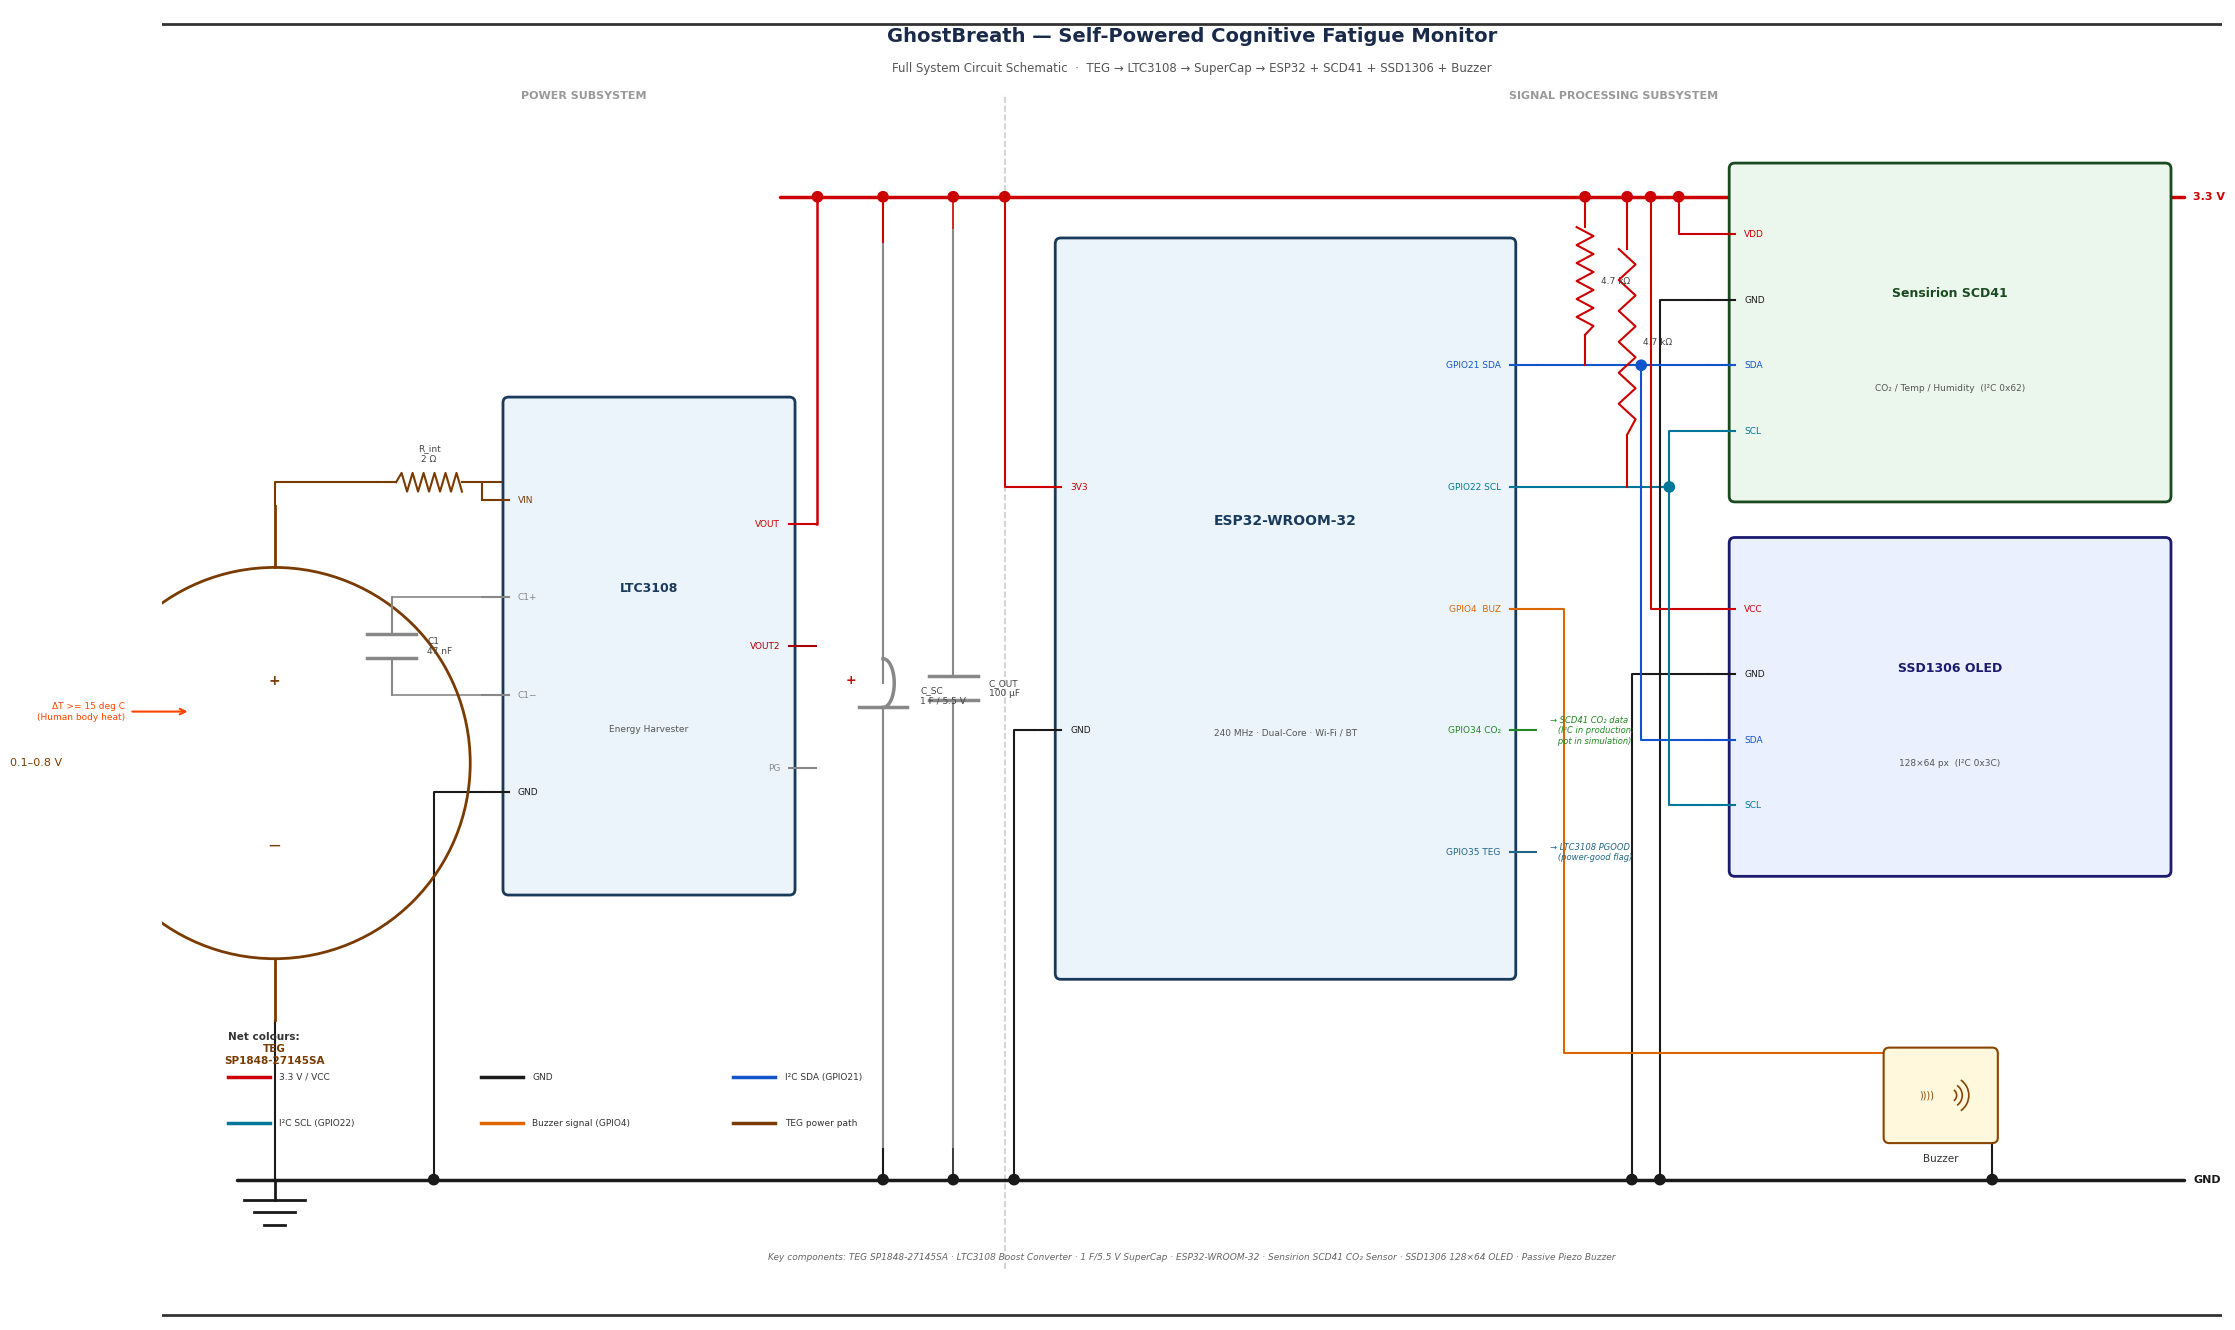

Saved → figures/07_ghostbreath_circuit_schematic.png


In [3]:
# ════════════════════════════════════════════════════════════════════════════
#  GhostBreath Full System Circuit Schematic
# ════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(22, 14))
ax.set_xlim(0, 22)
ax.set_ylim(0, 14)
ax.set_aspect("equal")
ax.axis("off")
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

# ── Background border ────────────────────────────────────────────────────────
ax.add_patch(FancyBboxPatch((0.1, 0.35), 21.8, 13.2,
             boxstyle="square", lw=2, edgecolor="#333", facecolor="white"))

# ── Title block ──────────────────────────────────────────────────────────────
ax.text(11, 13.72,
        "GhostBreath — Self-Powered Cognitive Fatigue Monitor",
        ha="center", va="center", fontsize=14, fontweight="bold", color="#1A2A4A")
ax.text(11, 13.38,
        "Full System Circuit Schematic  ·  TEG → LTC3108 → SuperCap → ESP32 + SCD41 + SSD1306 + Buzzer",
        ha="center", va="center", fontsize=8.5, color="#555")

# Section labels
ax.plot([9.0, 9.0], [0.55, 13.1], "--", color="#CCCCCC", lw=1.2, zorder=1)
ax.text(4.5, 13.05, "POWER SUBSYSTEM", ha="center", fontsize=8,
        color="#999", fontweight="bold")
ax.text(15.5, 13.05, "SIGNAL PROCESSING SUBSYSTEM", ha="center", fontsize=8,
        color="#999", fontweight="bold")

# ── Power rails ──────────────────────────────────────────────────────────────
VCC_Y = 12.0
GND_Y = 1.5

# 3.3 V rail
wire(ax, [(6.6, VCC_Y), (21.6, VCC_Y)], RED, lw=2.5)
ax.text(21.7, VCC_Y, "3.3 V", va="center", fontsize=8, color=RED, fontweight="bold")

# GND rail
wire(ax, [(0.8, GND_Y), (21.6, GND_Y)], BLK, lw=2.5)
ax.text(21.7, GND_Y, "GND", va="center", fontsize=8, color=BLK, fontweight="bold")

# ── TEG (Thermoelectric Generator) ───────────────────────────────────────────
TEG_CX = 1.2
TEG_BOT = 3.2
TEG_H = 5.5
TEG_TOP = TEG_BOT + TEG_H

draw_source_v(ax, TEG_CX, TEG_BOT, TEG_H, v_label="0.1–0.8 V", name_label="TEG\nSP1848-27145SA")

# Heat source annotation
ax.annotate("", xy=(TEG_CX - 0.90, TEG_BOT + TEG_H * 0.6),
            xytext=(TEG_CX - 1.55, TEG_BOT + TEG_H * 0.6),
            arrowprops=dict(arrowstyle="->", color="#FF4400", lw=1.5))
ax.text(TEG_CX - 1.60, TEG_BOT + TEG_H * 0.6,
        "ΔT >= 15 deg C\n(Human body heat)",
        ha="right", va="center", fontsize=6.5, color="#FF4400")

# TEG − to GND rail
wire(ax, [(TEG_CX, TEG_BOT), (TEG_CX, GND_Y)], BLK, lw=1.5)
draw_gnd(ax, TEG_CX, GND_Y)

# TEG + wire to R_int
wire(ax, [(TEG_CX, TEG_TOP), (TEG_CX, TEG_TOP + 0.25), (2.30, TEG_TOP + 0.25)], BROWN, lw=1.5)

# R_int (2 Ω internal resistance)
draw_resistor_h(ax, 2.30, TEG_TOP + 0.25, 1.10, "R_int\n2 Ω", BROWN)
wire(ax, [(3.40, TEG_TOP + 0.25), (3.70, TEG_TOP + 0.25)], BROWN, lw=1.5)

# ── LTC3108 Boost Converter ───────────────────────────────────────────────────
LTC_X, LTC_Y = 3.70, 4.6
LTC_W, LTC_H = 3.00, 5.2

ltc = draw_ic_box(ax, LTC_X, LTC_Y, LTC_W, LTC_H,
                  "LTC3108", "Energy Harvester",
                  left_pins=[
                      ("VIN",  BROWN),
                      ("C1+",  GREY),
                      ("C1−",  GREY),
                      ("GND",  BLK),
                  ],
                  right_pins=[
                      ("VOUT",  RED),
                      ("VOUT2", "#AA0000"),
                      ("PG",    GREY),
                  ])

# Wire R_int output → LTC3108 VIN
vin_y = ltc["L_VIN"][1]
wire(ax, [(3.70 - 0.28, TEG_TOP + 0.25), (3.70 - 0.28, vin_y), ltc["L_VIN"]], BROWN, lw=1.5)

# Flying capacitor C1 (47 nF) between C1+ and C1−
c1p_y = ltc["L_C1+"][1]
c1m_y = ltc["L_C1−"][1]
C1_X = LTC_X - 1.25
wire(ax, [ltc["L_C1+"], (C1_X, c1p_y)], GREY, lw=1.2)
draw_cap_v(ax, C1_X, c1m_y, c1p_y - c1m_y, "C1\n47 nF")
wire(ax, [(C1_X, c1m_y), ltc["L_C1−"]], GREY, lw=1.2)

# LTC3108 GND to GND rail
ltc_gnd_y = ltc["L_GND"][1]
wire(ax, [ltc["L_GND"], (LTC_X - 0.80, ltc_gnd_y), (LTC_X - 0.80, GND_Y)], BLK, lw=1.5)
dot(ax, LTC_X - 0.80, GND_Y, BLK)

# LTC3108 VOUT → VCC rail via vertical wire
vout_x, vout_y = ltc["R_VOUT"]
wire(ax, [ltc["R_VOUT"], (7.0, vout_y), (7.0, VCC_Y)], RED, lw=1.8)
dot(ax, 7.0, VCC_Y, RED)

# ── Supercapacitor (1 F / 5.5 V) ─────────────────────────────────────────────
SC_X = 7.7
SC_BOT = GND_Y + 0.35
SC_HEIGHT = VCC_Y - SC_BOT - 0.50   # leaves 0.5 gap to VCC rail
draw_supercap_v(ax, SC_X, SC_BOT, SC_HEIGHT, "C_SC\n1 F / 5.5 V")
wire(ax, [(SC_X, SC_BOT + SC_HEIGHT), (SC_X, VCC_Y)], RED, lw=1.5)
dot(ax, SC_X, VCC_Y, RED)
wire(ax, [(SC_X, SC_BOT), (SC_X, GND_Y)], BLK, lw=1.5)
dot(ax, SC_X, GND_Y, BLK)

# ── Output bypass cap (100 µF) ────────────────────────────────────────────────
BC_X = 8.45
draw_cap_v(ax, BC_X, GND_Y + 0.35, VCC_Y - GND_Y - 0.70, "C_OUT\n100 µF")
wire(ax, [(BC_X, VCC_Y - 0.35), (BC_X, VCC_Y)], RED, lw=1.2)
dot(ax, BC_X, VCC_Y, RED)
wire(ax, [(BC_X, GND_Y + 0.35), (BC_X, GND_Y)], BLK, lw=1.2)
dot(ax, BC_X, GND_Y, BLK)

# ── ESP32-WROOM-32 ────────────────────────────────────────────────────────────
ESP_X, ESP_Y = 9.6, 3.7
ESP_W, ESP_H = 4.8, 7.8

esp = draw_ic_box(ax, ESP_X, ESP_Y, ESP_W, ESP_H,
                  "ESP32-WROOM-32",
                  "240 MHz · Dual-Core · Wi-Fi / BT",
                  left_pins=[
                      ("3V3", RED),
                      ("GND", BLK),
                  ],
                  right_pins=[
                      ("GPIO21 SDA", BLUE),
                      ("GPIO22 SCL", CYAN),
                      ("GPIO4  BUZ", ORANGE),
                      ("GPIO34 CO₂", "#228822"),
                      ("GPIO35 TEG", "#226688"),
                  ],
                  tsz=10)

# ESP32 3V3 ← VCC rail
esp_3v3 = esp["L_3V3"]
wire(ax, [esp_3v3, (9.0, esp_3v3[1]), (9.0, VCC_Y)], RED, lw=1.5)
dot(ax, 9.0, VCC_Y, RED)

# ESP32 GND → GND rail
esp_gnd = esp["L_GND"]
wire(ax, [esp_gnd, (9.1, esp_gnd[1]), (9.1, GND_Y)], BLK, lw=1.5)
dot(ax, 9.1, GND_Y, BLK)

# ── I²C bus ───────────────────────────────────────────────────────────────────
sda_pin = esp["R_GPIO21 SDA"]
scl_pin = esp["R_GPIO22 SCL"]

# Horizontal bus wires from ESP32 rightward
SDA_BUS_X = 15.8
SCL_BUS_X = 16.1
wire(ax, [sda_pin, (SDA_BUS_X, sda_pin[1])], BLUE, lw=1.5)
wire(ax, [scl_pin, (SCL_BUS_X, scl_pin[1])], CYAN, lw=1.5)

# Pull-up resistors (4.7 kΩ, vertical) to VCC
PULLUP_X_SDA = ESP_X + ESP_W + 0.80
PULLUP_X_SCL = ESP_X + ESP_W + 1.25
draw_resistor_v(ax, PULLUP_X_SDA, sda_pin[1], VCC_Y - sda_pin[1], "4.7 kΩ", RED)
draw_resistor_v(ax, PULLUP_X_SCL, scl_pin[1], VCC_Y - scl_pin[1], "4.7 kΩ", RED)
dot(ax, PULLUP_X_SDA, VCC_Y, RED)
dot(ax, PULLUP_X_SCL, VCC_Y, RED)

# ── SCD41 CO₂ Sensor ──────────────────────────────────────────────────────────
SCD_X, SCD_Y = 16.8, 8.8
SCD_W, SCD_H = 4.6, 3.5

scd = draw_ic_box(ax, SCD_X, SCD_Y, SCD_W, SCD_H,
                  "Sensirion SCD41",
                  "CO₂ / Temp / Humidity  (I²C 0x62)",
                  left_pins=[
                      ("VDD", RED),
                      ("GND", BLK),
                      ("SDA", BLUE),
                      ("SCL", CYAN),
                  ],
                  fc=SENBG, ec=SENFG)

# SCD41 power
scd_vdd = scd["L_VDD"]
wire(ax, [scd_vdd, (16.2, scd_vdd[1]), (16.2, VCC_Y)], RED, lw=1.5)
dot(ax, 16.2, VCC_Y, RED)
scd_gnd = scd["L_GND"]
wire(ax, [scd_gnd, (16.0, scd_gnd[1]), (16.0, GND_Y)], BLK, lw=1.5)
dot(ax, 16.0, GND_Y, BLK)

# SCD41 I²C — branch from horizontal bus
scd_sda = scd["L_SDA"]
wire(ax, [(SDA_BUS_X, sda_pin[1]), (SDA_BUS_X, scd_sda[1]), scd_sda], BLUE, lw=1.5)
dot(ax, SDA_BUS_X, sda_pin[1], BLUE)
scd_scl = scd["L_SCL"]
wire(ax, [(SCL_BUS_X, scl_pin[1]), (SCL_BUS_X, scd_scl[1]), scd_scl], CYAN, lw=1.5)
dot(ax, SCL_BUS_X, scl_pin[1], CYAN)

# ── SSD1306 OLED Display ──────────────────────────────────────────────────────
OL_X, OL_Y = 16.8, 4.8
OL_W, OL_H = 4.6, 3.5

oled = draw_ic_box(ax, OL_X, OL_Y, OL_W, OL_H,
                   "SSD1306 OLED",
                   "128×64 px  (I²C 0x3C)",
                   left_pins=[
                       ("VCC", RED),
                       ("GND", BLK),
                       ("SDA", BLUE),
                       ("SCL", CYAN),
                   ],
                   fc=OLDBG, ec=OLDFG)

# OLED power
oled_vcc = oled["L_VCC"]
wire(ax, [oled_vcc, (15.9, oled_vcc[1]), (15.9, VCC_Y)], RED, lw=1.5)
dot(ax, 15.9, VCC_Y, RED)
oled_gnd = oled["L_GND"]
wire(ax, [oled_gnd, (15.7, oled_gnd[1]), (15.7, GND_Y)], BLK, lw=1.5)
dot(ax, 15.7, GND_Y, BLK)

# OLED I²C — branch from bus
oled_sda = oled["L_SDA"]
wire(ax, [(SDA_BUS_X, sda_pin[1]), (SDA_BUS_X, oled_sda[1]), oled_sda], BLUE, lw=1.5)
oled_scl = oled["L_SCL"]
wire(ax, [(SCL_BUS_X, scl_pin[1]), (SCL_BUS_X, oled_scl[1]), oled_scl], CYAN, lw=1.5)

# ── Piezo Buzzer ──────────────────────────────────────────────────────────────
BUZ_CX, BUZ_CY = 19.0, 2.4
draw_buzzer(ax, BUZ_CX, BUZ_CY)

# GPIO4 → buzzer
buz_pin = esp["R_GPIO4  BUZ"]
wire(ax, [buz_pin,
          (buz_pin[0] + 0.3, buz_pin[1]),
          (buz_pin[0] + 0.3, BUZ_CY + 0.45),
          (BUZ_CX - 0.55, BUZ_CY + 0.45)], ORANGE, lw=1.5)

# Buzzer GND
wire(ax, [(BUZ_CX + 0.55, BUZ_CY - 0.45), (BUZ_CX + 0.55, GND_Y)], BLK, lw=1.5)
dot(ax, BUZ_CX + 0.55, GND_Y, BLK)

# ── ADC note labels ───────────────────────────────────────────────────────────
co2_adc = esp["R_GPIO34 CO₂"]
teg_adc = esp["R_GPIO35 TEG"]
ax.text(co2_adc[0] + 0.15, co2_adc[1],
        "→ SCD41 CO₂ data\n   (I²C in production;\n   pot in simulation)",
        va="center", fontsize=6.0, color="#228822", style="italic")
ax.text(teg_adc[0] + 0.15, teg_adc[1],
        "→ LTC3108 PGOOD\n   (power-good flag)",
        va="center", fontsize=6.0, color="#226688", style="italic")

# ── Legend ────────────────────────────────────────────────────────────────────
LEGEND = [
    (RED,    "3.3 V / VCC"),
    (BLK,    "GND"),
    (BLUE,   "I²C SDA (GPIO21)"),
    (CYAN,   "I²C SCL (GPIO22)"),
    (ORANGE, "Buzzer signal (GPIO4)"),
    (BROWN,  "TEG power path"),
]
ax.text(0.7, 3.0, "Net colours:", fontsize=7.5, color="#333", fontweight="bold")
for i, (c, label) in enumerate(LEGEND):
    col_i = i % 3
    row_i = i // 3
    lx = 0.7 + col_i * 2.70
    ly = 2.60 - row_i * 0.50
    ax.plot([lx, lx + 0.45], [ly, ly], color=c, lw=2.5)
    ax.text(lx + 0.55, ly, label, va="center", fontsize=6.5, color="#333")

# ── Footer ────────────────────────────────────────────────────────────────────
ax.text(11, 0.62,
        "Key components: TEG SP1848-27145SA · LTC3108 Boost Converter · 1 F/5.5 V SuperCap · "
        "ESP32-WROOM-32 · Sensirion SCD41 CO₂ Sensor · SSD1306 128×64 OLED · Passive Piezo Buzzer",
        ha="center", va="bottom", fontsize=6.5, color="#666", style="italic")

plt.tight_layout(pad=0.3)
OUT = "figures/07_ghostbreath_circuit_schematic.png"
plt.savefig(OUT, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {OUT}")


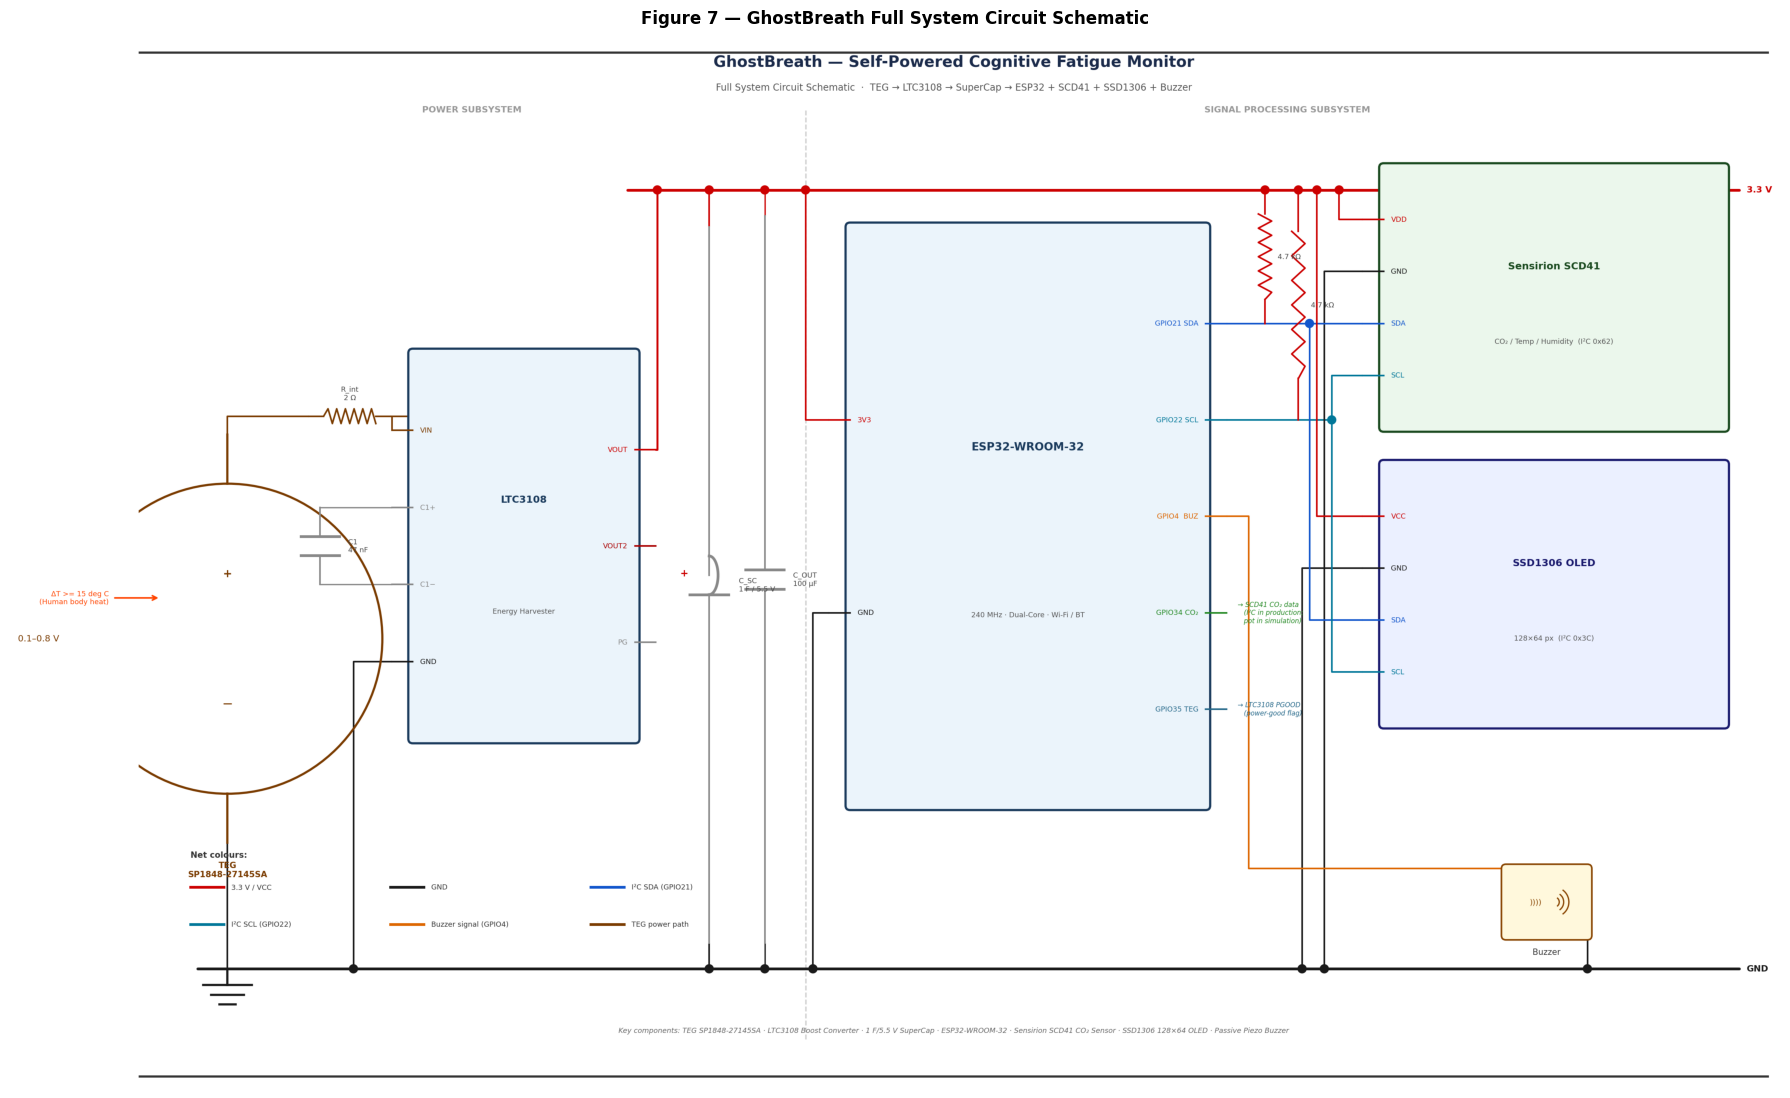

In [4]:
import matplotlib.image as mpimg

img = mpimg.imread("figures/07_ghostbreath_circuit_schematic.png")
fig, ax = plt.subplots(figsize=(18, 11))
ax.imshow(img)
ax.axis("off")
ax.set_title("Figure 7 — GhostBreath Full System Circuit Schematic",
             fontsize=12, fontweight="bold", pad=8)
plt.tight_layout()
plt.show()


## Bill of Materials

| Ref | Component | Part Number | Value / Spec | Notes |
|-----|-----------|-------------|-------------|-------|
| U1 | Thermoelectric Generator | SP1848-27145SA | ΔT ≥ 15 °C → 0.3 V | Available on AliExpress / Amazon |
| U2 | Energy harvesting IC | LTC3108 | V_IN min 20 mV | Also supports LTC3109 for bidirectional |
| C1 | Flying capacitor | — | 47 nF ceramic | Required for LTC3108 charge pump |
| C_SC | Supercapacitor | — | 1 F / 5.5 V | Panasonic EEC-EN0F105 or equivalent |
| C_OUT | Bypass capacitor | — | 100 µF / 6.3 V | Tantalum or low-ESR electrolytic |
| U3 | Microcontroller | ESP32-WROOM-32 | 240 MHz, 4 MB Flash | Devkit v1 for prototyping |
| U4 | CO₂ sensor | Sensirion SCD41 | I²C 0x62, 400 ppm–5000 ppm | ±40 ppm accuracy |
| U5 | OLED display | SSD1306 128×64 | I²C 0x3C | 0.96" module, 3.3 V compatible |
| R1, R2 | I²C pull-up resistors | — | 4.7 kΩ | One per bus line (SDA, SCL) |
| BZ1 | Piezo buzzer | — | Passive, 3.3 V rated | Driven by GPIO4 via `tone()` at 1 kHz |

### Power budget (from Module 2 analysis)

| Item | Power |
|------|-------|
| TEG output (ΔT = 15 °C, 50% coupling efficiency) | 6.05 mW |
| ESP32 deep-sleep + periodic wake @ T = 300 s | 0.50 mW average |
| Available headroom | **12 × margin** |
| Supercapacitor holds enough energy for | > 10 000 wake cycles |
